# Netflix Titles Analysis

## Research Questions
1. How has the number of titles added to Netflix changed over time (by year)?
2. Do Movies and TV Shows differ in typical duration (minutes vs. seasons) or in ratings distribution?

This notebook analyzes the Netflix titles dataset to explore trends over time and duration and rating differences between Movies and TV Shows.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")



In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Dictionary

- show_id: Unique ID for each title
- type: Movie or TV Show
- title: Title name
- director: Director of the title
- cast: Main actors
- country: Country of production
- date_added: Date added to Netflix
- release_year: Year the title was released
- rating: Age rating (TV-MA, PG, etc.)
- duration: Length (minutes for Movies, seasons for TV Shows)
- listed_in: Genre/category
- description: Short summary


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year


In [5]:
def clean_duration(duration):
    if pd.isnull(duration):
        return None
    return int(duration.split(" ")[0])

df['duration_clean'] = df['duration'].apply(clean_duration)


In [6]:
df = df.dropna(subset=['year_added', 'duration_clean'])


# Analysis 1: Titles Added Per Year


In [7]:
titles_per_year = df.groupby('year_added').size()
titles_per_year


year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     416
2017.0    1163
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
dtype: int64

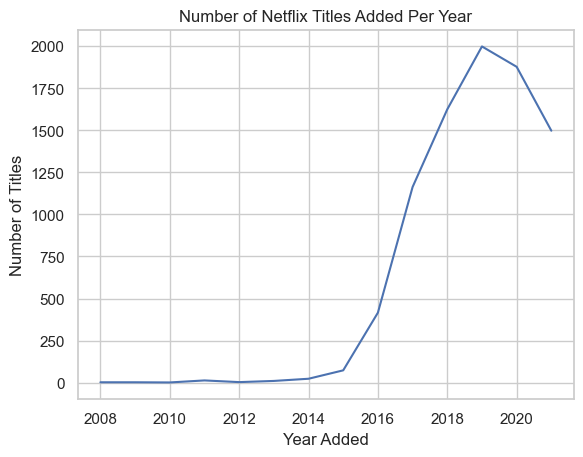

In [8]:
plt.figure()
titles_per_year.plot()
plt.title("Number of Netflix Titles Added Per Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()


### Interpretation

The number of titles added to Netflix increases significantly after 2015 and peaks around 2018–2019. This suggets a period of rapid growth, maybe trying to compete with others in the market. After 2019, there is a steady decline.


# Analysis 2: Duration Comparison Between Movies and TV Shows


In [9]:
df['type'].value_counts()


type
Movie      6128
TV Show    2578
Name: count, dtype: int64

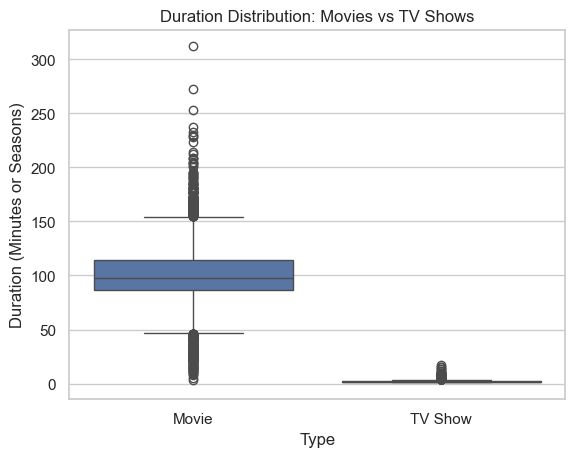

In [10]:
plt.figure()
sns.boxplot(x='type', y='duration_clean', data=df)
plt.title("Duration Distribution: Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Duration (Minutes or Seasons)")
plt.show()


### Interpretation

Movies typically have durations concentrated around 90–120 minutes, showing the standard length of cinema. TV Shows have smaller numeric values because duration represents number of seasons rather than minutes. This highlights a structural difference between Movies and TV Shows.
